This notebook allows the user to visualize their team's regular season stats. It includes scatterplots that show power play and penalty kill efficiency, as well as graphs that compare various metrics in games won vs. in games lost.

The user should modify the variable `team` in the second code cell.

In [1]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

sys.path.append("../src")
from fetch_gamelog import gamelog


In [2]:
team = "" #user input
team_gamelog = gamelog(team)
length = team_gamelog.shape[0]

HTTPError: 404 Client Error: Not Found for url: https://www.hockey-reference.com/teams//2026_gamelog.html

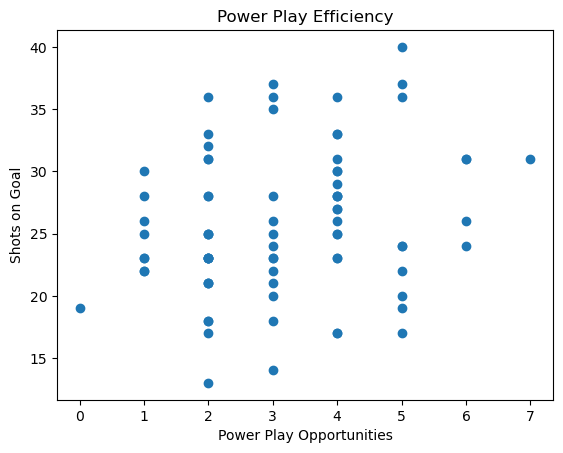

In [ ]:
#Power Play Opportunities vs. Shots on Goal

data1 = np.asarray(team_gamelog[("Team", "PPO")])
data2 = np.asarray(team_gamelog[("Team", "SOG")])
plt.scatter(data1, data2);
plt.xlabel("Power Play Opportunities");
plt.ylabel("Shots on Goal");
plt.title("Power Play Efficiency"); #is efficiency the right word here?

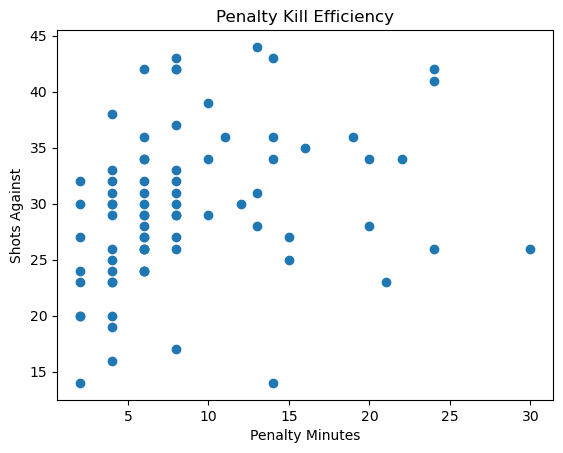

In [ ]:
#Penalties in Minutes vs. Shots Against
#A different way of visualizing penalties/ penalty kill efficiency

data1 = np.asarray(team_gamelog[("Team", "PIM")])
data2 = np.asarray(team_gamelog[("Opponent", "SOG")])
plt.scatter(data1, data2)
plt.xlabel("Penalty Minutes");
plt.ylabel("Shots Against");
plt.title("Penalty Kill Efficiency");

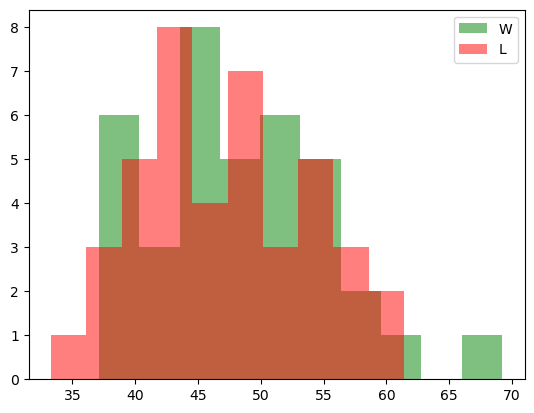

In [ ]:
#Faceoff% vs. Result
data1 = team_gamelog[team_gamelog[('Score', 'Rslt')] == 'W'][('Faceoffs', 'FO%')].tolist()
data2 = team_gamelog[team_gamelog[('Score', 'Rslt')] == 'L'][('Faceoffs', 'FO%')].tolist()
plt.hist(data1, color = "green", label = "W", alpha = 0.5);
plt.hist(data2, color = "red", label = "L", alpha = 0.5);
plt.legend();

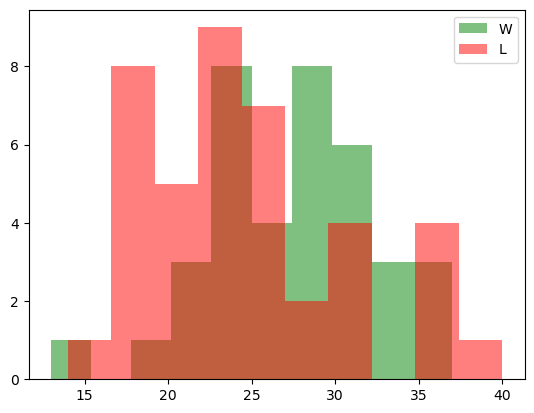

In [ ]:
#Shots on Goal vs. Result
data1 = team_gamelog[team_gamelog[('Score', 'Rslt')] == 'W'][('Team', 'SOG')].tolist()
data2 = team_gamelog[team_gamelog[('Score', 'Rslt')] == 'L'][('Team', 'SOG')].tolist()
plt.hist(data1, color = "green", label = "W", alpha = 0.5);
plt.hist(data2, color = "red", label = "L", alpha = 0.5);
plt.legend();

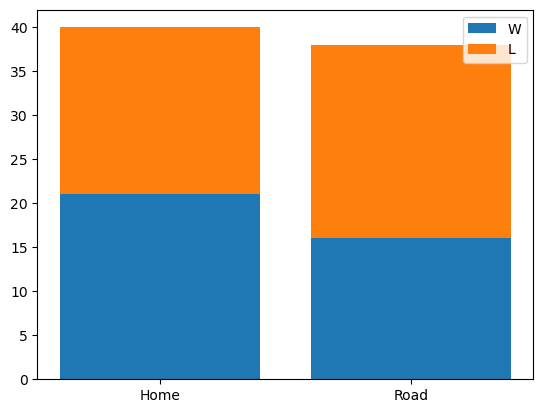

In [ ]:
#Home vs. Road Games

home_wins = 0
road_wins = 0
home_losses = 0
road_losses = 0

for i in range(length):
    if team_gamelog.iloc[i][('Score', 'Rslt')] == 'W':
        if team_gamelog.iloc[i][(('Unnamed: 3_level_0', 'Unnamed: 3_level_1'))] != '@':
            home_wins += 1
        else:
            road_wins += 1
    else:
        if team_gamelog.iloc[i][(('Unnamed: 3_level_0', 'Unnamed: 3_level_1'))] != '@':
            home_losses +=1
        else:
            road_losses += 1

x = ["Home Games", "Road Games"]
y1 = [home_wins, road_wins]
y2 = [home_losses, road_losses]

plt.bar(x, y1, label = 'W', color = "green");
plt.bar(x, y2, bottom=y1, label = 'L', color = "red");
plt.legend();
plt.show();